# PINN 求解氢原子前三个本征态 (1s, 2s, 3s)

在这个 Notebook 中，我们使用 **正交惩罚法 (Deflation/Orthogonalization)** 来依次求解氢原子的前三个本征态。

## 核心原理：正交性约束
在量子力学中，不同能级的本征波函数 $\psi_n$ 是相互正交的：
$$ \int \psi_m(\mathbf{r}) \psi_n(\mathbf{r}) d\mathbf{r} = 0 \quad (m \neq n) $$

我们将分步训练三个神经网络：
1. **训练 $\psi_1$ (基态)**：正常求解 PDE。
2. **训练 $\psi_2$ (第一激发态)**：在 PDE 损失的基础上，增加与 $\psi_1$ 的正交损失：$Loss_{orth} = \lambda (\int \psi_2 \psi_1 d\mathbf{r})^2$。
3. **训练 $\psi_3$ (第二激发态)**：增加与 $\psi_1$ 和 $\psi_2$ 的双重正交损失。

对应能量 (Atomic Units):
- $n=1$: $E_1 = -0.5$
- $n=2$: $E_2 = -0.125$
- $n=3$: $E_3 = -0.0556$

In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


In [19]:
class AtomicNet(nn.Module):
    def __init__(self):
        super(AtomicNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, r_coords):
        return self.net(r_coords)

In [20]:
def calc_pde_loss(model, x, y, z, E):
    psi = model(torch.cat([x, y, z], dim=1))
    
    # 自动求导算拉普拉斯项
    def get_grad2(f, var):
        g = torch.autograd.grad(f, var, grad_outputs=torch.ones_like(f), create_graph=True)[0]
        g2 = torch.autograd.grad(g, var, grad_outputs=torch.ones_like(g), create_graph=True)[0]
        return g2

    laplacian = get_grad2(psi, x) + get_grad2(psi, y) + get_grad2(psi, z)
    
    r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)
    # PDE: -0.5 * r * laplacian - psi = E * r * psi (消除1/r奇点)
    residual = -0.5 * r * laplacian - psi - E * r * psi
    return torch.mean(residual**2)

In [21]:
def train_state(n, energy, prev_models=None):
    print(f"\n--- 正在训练第 {n} 本征态 (E={energy:.4f}) ---")
    model = AtomicNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # 配点采样
    N_f = 4000
    fixed_range = 6.0
    x_f = torch.FloatTensor(N_f, 1).uniform_(-fixed_range, fixed_range).to(device).requires_grad_(True)
    y_f = torch.FloatTensor(N_f, 1).uniform_(-fixed_range, fixed_range).to(device).requires_grad_(True)
    z_f = torch.FloatTensor(N_f, 1).uniform_(-fixed_range, fixed_range).to(device).requires_grad_(True)
    
    epochs = 4000
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # 1. PDE Loss
        loss_pde = calc_pde_loss(model, x_f, y_f, z_f, energy)
        
        # 2. Orthogonality Loss (与之前所有态正交)
        loss_orth = 0
        psi_current = model(torch.cat([x_f, y_f, z_f], dim=1))
        if prev_models:
            for prev_m in prev_models:
                prev_m.eval()
                with torch.no_grad():
                    psi_prev = prev_m(torch.cat([x_f, y_f, z_f], dim=1))
                # 积分正交项: (mean(psi_n * psi_m))^2
                loss_orth += torch.mean(psi_current * psi_prev)**2 * 100.0
        
        # 3. 边界与中心约束 (1s, 2s, 3s 在原点不为0)
        psi_0 = model(torch.zeros(1, 3).to(device))
        # 为了区分态，可以根据n给不同的中心初值或干脆只用归一化
        loss_ic = torch.mean((psi_0 - 1.0)**2)
        
        total_loss = loss_pde + loss_orth + loss_ic
        total_loss.backward()
        optimizer.step()
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | PDE: {loss_pde.item():.4e} | Orth: {loss_orth if isinstance(loss_orth, int) else loss_orth.item():.4e}")
            
    return model

In [22]:
models = []
energies = [-0.5, -0.125, -0.0556]

for i, E in enumerate(energies):
    m = train_state(i+1, E, prev_models=models)
    models.append(m)


--- 正在训练第 1 本征态 (E=-0.5000) ---


Epoch 0 | PDE: 5.1088e-02 | Orth: 0.0000e+00
Epoch 1000 | PDE: 2.3863e-04 | Orth: 0.0000e+00
Epoch 2000 | PDE: 1.4039e-04 | Orth: 0.0000e+00
Epoch 3000 | PDE: 9.1744e-05 | Orth: 0.0000e+00
Epoch 4000 | PDE: 4.1818e-05 | Orth: 0.0000e+00

--- 正在训练第 2 本征态 (E=-0.1250) ---
Epoch 0 | PDE: 4.3119e-03 | Orth: 3.3847e-04
Epoch 1000 | PDE: 5.7207e-04 | Orth: 7.3605e-05
Epoch 2000 | PDE: 1.6814e-04 | Orth: 2.1179e-06
Epoch 3000 | PDE: 6.8963e-05 | Orth: 5.3300e-08
Epoch 4000 | PDE: 3.8647e-05 | Orth: 1.4593e-07

--- 正在训练第 3 本征态 (E=-0.0556) ---
Epoch 0 | PDE: 1.0677e-02 | Orth: 1.4851e-03
Epoch 1000 | PDE: 5.8447e-04 | Orth: 1.1045e-04
Epoch 2000 | PDE: 1.4096e-04 | Orth: 4.1390e-06
Epoch 3000 | PDE: 5.9778e-05 | Orth: 1.6079e-06
Epoch 4000 | PDE: 3.3162e-05 | Orth: 9.7559e-07


## 3D 可视化对比

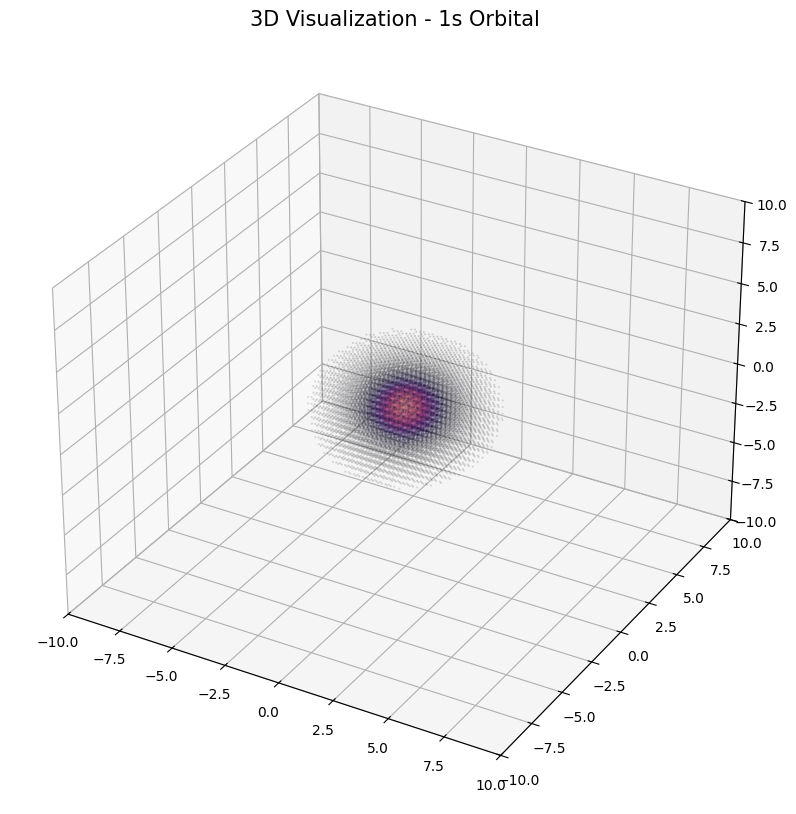

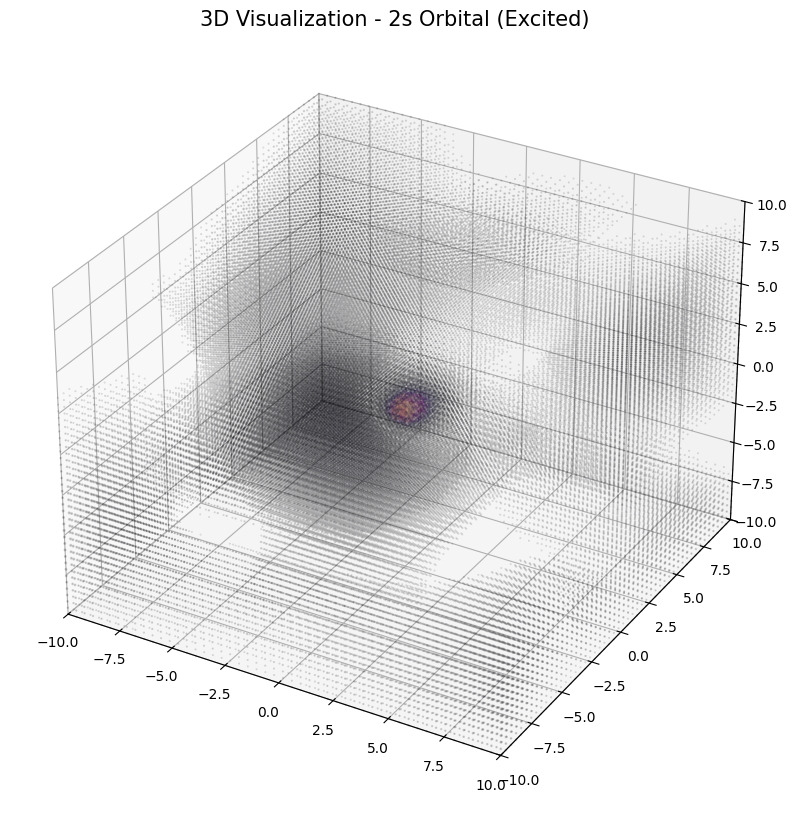

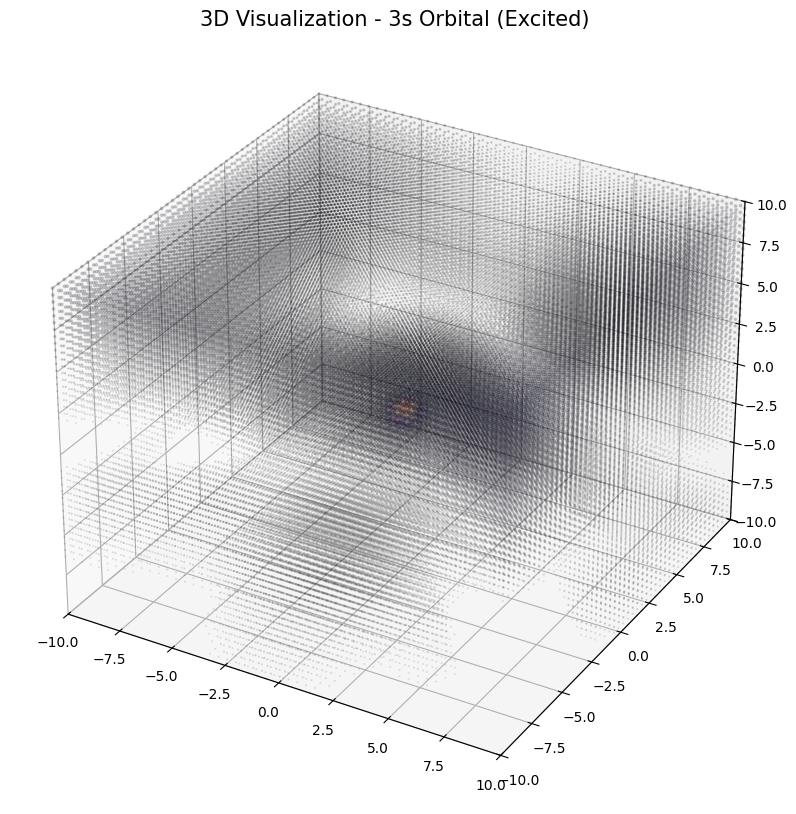

In [32]:
titles = ["1s Orbital", "2s Orbital (Excited)", "3s Orbital (Excited)"]

# 循环创建三个独立的 3D 图
for i in range(3):
    fig = plt.figure(figsize=(12, 10)) # 设置为您需要的大尺寸
    ax = fig.add_subplot(111, projection='3d')
    
    # 增加采样密度到 50，让云图更细腻
    grid = 50 
    l = np.linspace(-10, 10, grid)
    X, Y, Z = np.meshgrid(l, l, l)
    pts = torch.FloatTensor(np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)).to(device)
    
    models[i].eval()
    with torch.no_grad():
        psi = models[i](pts).cpu().numpy().flatten()
    
    density = psi**2
    # 关键：调低阈值到 0.001，确保 2s/3s 的外层结构不被滤掉
    mask = density > 0.001 * density.max()
    
    # 渲染散点云
    sc = ax.scatter(X.flatten()[mask], Y.flatten()[mask], Z.flatten()[mask], 
                    c=density[mask], cmap='magma', alpha=0.15, s=density[mask]*200)
    
    # 核心：统一坐标轴范围，防止自动缩放导致尺寸错觉
    limit = 10
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    ax.set_title(f"3D Visualization - {titles[i]}", fontsize=15)
    plt.show() # 每个循环强制显示一张图
